# Problem 2

## Benders decomposition

In [136]:
# Benders approach:
#   - Master: y_coal, y_gas, alpha
#   - Subproblem (for each scenario): fix y_coal,y_gas, solve LP -> dual -> Benders cut.
# ---------------------------------------------------------
import gurobipy as gp
from gurobipy import GRB

def solve_benders_fuel_procurement():
    # ------------------
    # 1) Problem Data

    fuels = ["coal", "gas"]
    # Year-1 known demand
    D1 = 850.0

    # Year-1 costs
    cost_year1 = {
        "coal": 4.5,
        "gas":  5.1
    }

    # Scenarios for Year-2
    scenarios = ["High", "Medium", "Low"]

    # Probability of each scenario
    prob = {
        "High":   0.3,
        "Medium": 0.4,
        "Low":    0.3
    }

    # Additional (Year-2) demand
    D2 = {
        "High":   950.0,
        "Medium": 780.0,
        "Low":    530.0
    }

    # Year-2 costs
    cost_year2 = {
        ("coal", "High"):   7.5,
        ("gas",  "High"):   8.5,
        ("coal", "Medium"): 6.0,
        ("gas",  "Medium"): 5.5,
        ("coal", "Low"):    3.0,
        ("gas",  "Low"):    4.0
    }

    # ----------------------
    # 2) Master Model

    master = gp.Model("BendersMaster")
    master.setParam("OutputFlag", 0)  # Silence standard Gurobi output

    # First-stage variables: y_coal, y_gas >= 0
    y = {}
    for f in fuels:
        y[f] = master.addVar(lb=0.0, name=f"y_{f}")

    # Alpha >= 0 for second-stage cost
    alpha = master.addVar(lb=0.0, name="Alpha")

    # Year-1 demand constraint: y_coal + y_gas >= 850
    master.addConstr(y["coal"] + y["gas"] >= D1, name="Year1Demand")

    # Master objective: Min [first-stage cost + alpha]
    master.setObjective(
        cost_year1["coal"] * y["coal"] + cost_year1["gas"] * y["gas"] + alpha,
        GRB.MINIMIZE
    )
    master.update()

    # ----------------------
    # 3) Benders Iteration

    max_iters = 50
    tol = 1e-6

    iteration = 0
    LB = -float('inf')   # Master's lower bound
    UB = float('inf')    # Best feasible solution found so far
    best_y = None        # Store the best first-stage solution

    while iteration < max_iters and (UB - LB) > tol:
        iteration += 1

        # Solve (restricted) Master
        master.optimize()
        if master.status != GRB.OPTIMAL:
            print(f"Master problem infeasible or unbounded at iteration {iteration}!")
            break

        # Current Master obj => new LB
        master_obj_val = master.ObjVal
        LB = max(LB, master_obj_val)

        # Extract y* from Master
        y_sol = {f: y[f].X for f in fuels}

        print(f"\n--- Iteration {iteration} ---")
        print(f"Master solution: y_coal={y_sol['coal']:.4f}, y_gas={y_sol['gas']:.4f}, alpha={alpha.X:.4f}")
        print(f"Master objective (LB) = {master_obj_val:.4f}")

        # Solve each scenario subproblem
        total_expected_2nd_stage = 0.0

        # Expression for alpha >= 
        benders_cut_expr = 0.0

        for s in scenarios:
            # Build subproblem for scenario s
            subp = gp.Model(f"Subproblem_{s}")
            subp.setParam("OutputFlag", 0)

            # Year-2 decision variables
            x_coal = subp.addVar(lb=0.0, name=f"x_coal_{s}")
            x_gas  = subp.addVar(lb=0.0, name=f"x_gas_{s}")

            # Demand constraint: (y_coal + x_coal) + (y_gas + x_gas) >= 850 + D2[s]
            demand_constr = subp.addConstr(x_coal + x_gas >= (D1 + D2[s]) - (y_sol["coal"] + y_sol["gas"]), name="TotalDemand")
            

            # Balanced mix constraints
            low_bound = (1.0/3.0)*(D1 + D2[s])
            up_bound  = (2.0/3.0)*(D1 + D2[s])

            # Revised formulation: subtract fixed first-stage decisions from the bounds
            coal_lower_constr = subp.addConstr(x_coal >= low_bound - y_sol["coal"], name="CoalLower")
            coal_upper_constr = subp.addConstr(x_coal <= up_bound - y_sol["coal"], name="CoalUpper")

            gas_lower_constr  = subp.addConstr(x_gas >= low_bound - y_sol["gas"], name="GasLower")
            gas_upper_constr  = subp.addConstr(x_gas <= up_bound - y_sol["gas"], name="GasUpper")
    
            # Subproblem objective = scenario cost
            subp.setObjective(
                cost_year2[("coal", s)] * x_coal + cost_year2[("gas", s)] * x_gas,
                GRB.MINIMIZE
            )

            subp.optimize()
            if subp.status != GRB.OPTIMAL:
                raise RuntimeError(f"Scenario {s} subproblem infeasible.")

            scenario_opt_val = subp.ObjVal
            scenario_weighted_cost = prob[s] * scenario_opt_val
            total_expected_2nd_stage += scenario_weighted_cost

            # Gather duals
            pi_demand     = demand_constr.Pi
            pi_coal_lower = coal_lower_constr.Pi
            pi_coal_upper = coal_upper_constr.Pi
            pi_gas_lower  = gas_lower_constr.Pi
            pi_gas_upper  = gas_upper_constr.Pi

            # Summarize the dual for coal and gas in this scenario

            dual_coal_s = + pi_demand + pi_coal_lower + pi_coal_upper
            dual_gas_s  = + pi_demand + pi_gas_lower  + pi_gas_upper 

            # Benders cut for scenario s:
            # alpha >= p_s*(SubObjVal_s - [dual_coal_s*y_coal_sol + dual_gas_s*y_gas_sol])
            # + p_s*(dual_coal_s*y_coal + dual_gas_s*y_gas)
            cut_const_s = prob[s]*(scenario_opt_val
              - (dual_coal_s*y_sol["coal"] + dual_gas_s*y_sol["gas"]))
            cut_linear_s = prob[s]*(dual_coal_s*y["coal"] + dual_gas_s*y["gas"])
            scenario_cut_expr = cut_const_s + cut_linear_s
            benders_cut_expr += scenario_cut_expr

            # Print subproblem info
            print(f"Scenario {s} subproblem -> cost={scenario_opt_val:.2f}, x_coal={x_coal.X:.2f}, x_gas={x_gas.X:.2f}")
            print(f"   Duals -> dem={pi_demand:.3f}, cLow={pi_coal_lower:.3f}, cUp={pi_coal_upper:.3f},"
                  f" gLow={pi_gas_lower:.3f}, gUp={pi_gas_upper:.3f}")
            print(f"   Benders partial expr => + {cut_const_s:.2f} + ( {prob[s]*dual_coal_s:.2f}*y_coal + {prob[s]*dual_gas_s:.2f}*y_gas )")

        # Summarize feasible cost from subproblem solutions
        first_stage_cost_val = cost_year1["coal"]*y_sol["coal"] + cost_year1["gas"]*y_sol["gas"]
        feasible_obj_val = first_stage_cost_val + total_expected_2nd_stage

        if feasible_obj_val < UB:
            UB = feasible_obj_val
            best_y = y_sol

        # Add the overall Benders cut: alpha >= benders_cut_expr
        cutname = f"Benders cut iteration{iteration}"
        master.addConstr(alpha >= benders_cut_expr, name=cutname)
        master.update()

        # Print iteration summary
        gap = (UB - LB)/abs(UB) if abs(UB) > 1e-12 else float('inf')
        print(f"\nIteration {iteration} summary:")
        print(f"  Subproblem feasible cost = {feasible_obj_val:.2f}  -> UB = {UB:.2f}")
        print(f"  LB = {LB:.2f}, Gap = {gap*100:.4f}%")
        print(f"  Added Benders cut: {cutname}")

    # ----------------------------------
    # 4) Final results

    print("\nBenders Decomposition finished.")
    print(f"Total iterations = {iteration}")
    print(f"Final lower bound = {LB:.4f}")
    print(f"Final upper bound = {UB:.4f}")

    if best_y is not None:
        print(f"Best first-stage solution:\n  y_coal = {best_y['coal']:.4f}, y_gas = {best_y['gas']:.4f}")
        fs_cost = cost_year1["coal"]*best_y["coal"] + cost_year1["gas"]*best_y["gas"]
        print(f" First-stage cost = {fs_cost:.4f}")
    else:
        print("No feasible solution found (unexpected).")


def main():
    solve_benders_fuel_procurement()

if __name__ == "__main__":
    main()



--- Iteration 1 ---
Master solution: y_coal=850.0000, y_gas=0.0000, alpha=0.0000
Master objective (LB) = 3825.0000
Scenario High subproblem -> cost=7725.00, x_coal=350.00, x_gas=600.00
   Duals -> dem=8.500, cLow=0.000, cUp=-1.000, gLow=0.000, gUp=0.000
   Benders partial expr => + 405.00 + ( 2.25*y_coal + 2.55*y_gas )
Scenario Medium subproblem -> cost=4290.00, x_coal=0.00, x_gas=780.00
   Duals -> dem=5.500, cLow=0.000, cUp=0.000, gLow=0.000, gUp=0.000
   Benders partial expr => + -154.00 + ( 2.20*y_coal + 2.20*y_gas )
Scenario Low subproblem -> cost=2050.00, x_coal=70.00, x_gas=460.00
   Duals -> dem=4.000, cLow=0.000, cUp=-1.000, gLow=0.000, gUp=0.000
   Benders partial expr => + -150.00 + ( 0.90*y_coal + 1.20*y_gas )

Iteration 1 summary:
  Subproblem feasible cost = 8473.50  -> UB = 8473.50
  LB = 3825.00, Gap = 54.8593%
  Added Benders cut: Benders cut iteration1

--- Iteration 2 ---
Master solution: y_coal=850.0000, y_gas=0.0000, alpha=4648.5000
Master objective (LB) = 8473.50

In [146]:
import gurobipy as gp
from gurobipy import GRB

def solve_benders_fuel_procurement():
    # ------------------
    # 1) Problem Data (Same as before)
    # ... (rest of your data setup) ...
    fuels = ["coal", "gas"]
    D1 = 850.0
    cost_year1 = {"coal": 4.5, "gas": 5.1}
    scenarios = ["High", "Medium", "Low"]
    prob = {"High": 0.3, "Medium": 0.4, "Low": 0.3}
    D2 = {"High": 950.0, "Medium": 780.0, "Low": 530.0}
    cost_year2 = {
        ("coal", "High"): 7.5, ("gas", "High"): 8.5,
        ("coal", "Medium"): 6.0, ("gas", "Medium"): 5.5,
        ("coal", "Low"): 3.0, ("gas", "Low"): 4.0
    }

    # ----------------------
    # 2) Master Model (Same as before)
    master = gp.Model("BendersMaster")
    master.setParam("OutputFlag", 0)
    master.setParam("InfUnbdInfo", 1) # Needed to get Farkas duals

    y = {}
    for f in fuels:
        y[f] = master.addVar(lb=0.0, name=f"y_{f}")
    alpha = master.addVar(lb=0.0, name="Alpha") # Use non-negative alpha is typical
    master.addConstr(y["coal"] + y["gas"] >= D1, name="Year1Demand")
    master.setObjective(
        cost_year1["coal"] * y["coal"] + cost_year1["gas"] * y["gas"] + alpha,
        GRB.MINIMIZE
    )
    master.update()

    # ----------------------
    # 3) Benders Iteration

    max_iters = 500
    tol = 1e-2
    iteration = 0
    LB = 0
    UB = 20000
    best_y = None

    while iteration < max_iters and abs(UB - LB) >= tol * (1 + abs(LB)): # Use >= for gap check
        iteration += 1
        feasibility_cut_added_this_iter = False # Flag for feasibility cuts

        # Solve (restricted) Master
        master.optimize()
        if master.status == GRB.INFEASIBLE:
             print("Master problem became infeasible. Stopping.")
             break
        if master.status != GRB.OPTIMAL:
             print(f"Master problem stopped with status {master.status} at iteration {iteration}!")
             break

        master_obj_val = master.ObjVal
        # Alpha provides the lower bound part from cuts, so LB is master obj
        LB = max(LB, master_obj_val) # Update Lower Bound

        y_sol = {f: y[f].X for f in fuels}
        alpha_sol = alpha.X # Get alpha value as well

        print(f"\n--- Iteration {iteration} ---")
        print(f"Master solution: y_coal={y_sol['coal']:.4f}, y_gas={y_sol['gas']:.4f}, alpha={alpha_sol:.4f}")
        print(f"Master objective (LB) = {master_obj_val:.4f}")

        # --- Solve Subproblems ---
        total_expected_2nd_stage = 0.0
        # Expression for optimality cut: alpha >= benders_cut_expr
        benders_cut_expr = 0.0

        for s in scenarios:
            # Build subproblem for scenario s
            subp = gp.Model(f"Subproblem_{s}")
            subp.setParam("OutputFlag", 0)
            subp.setParam("InfUnbdInfo", 1) # Get Farkas dual if infeasible

            x_coal = subp.addVar(lb=0.0, name=f"x_coal_{s}")
            x_gas  = subp.addVar(lb=0.0, name=f"x_gas_{s}")

            # Constraints (using y_sol)
            TD_s = D1 + D2[s] # Total Demand for scenario s
            demand_rhs = TD_s - (y_sol["coal"] + y_sol["gas"])
            demand_constr = subp.addConstr(x_coal + x_gas >= demand_rhs, name="TotalDemand")

            low_bound = (1.0/3.0) * TD_s
            up_bound  = (2.0/3.0) * TD_s

            coal_lower_rhs = low_bound - y_sol["coal"]
            coal_upper_rhs = up_bound - y_sol["coal"] # This is RHS for x_coal <= ...
            gas_lower_rhs = low_bound - y_sol["gas"]
            gas_upper_rhs = up_bound - y_sol["gas"] # This is RHS for x_gas <= ...

            coal_lower_constr = subp.addConstr(x_coal >= coal_lower_rhs, name="CoalLower")
            coal_upper_constr = subp.addConstr(x_coal <= coal_upper_rhs, name="CoalUpper") # <= constraint
            gas_lower_constr  = subp.addConstr(x_gas >= gas_lower_rhs, name="GasLower")
            gas_upper_constr  = subp.addConstr(x_gas <= gas_upper_rhs, name="GasUpper") # <= constraint

            subp.setObjective(
                cost_year2[("coal", s)] * x_coal + cost_year2[("gas", s)] * x_gas,
                GRB.MINIMIZE
            )

            subp.optimize()

            # --- Process Subproblem Result ---
            if subp.status == GRB.OPTIMAL:
                scenario_opt_val = subp.ObjVal
                scenario_weighted_cost = prob[s] * scenario_opt_val
                total_expected_2nd_stage += scenario_weighted_cost

                # Gather duals for Optimality Cut
                pi_demand = demand_constr.Pi
                pi_coal_lower = coal_lower_constr.Pi
                # Dual for <= constraint (Gurobi returns non-positive)
                pi_coal_upper_raw = coal_upper_constr.Pi
                pi_gas_lower = gas_lower_constr.Pi
                # Dual for <= constraint (Gurobi returns non-positive)
                pi_gas_upper_raw = gas_upper_constr.Pi

                # Adjust signs for cut calculation (we want non-negative duals for standard forms)
                # For x <= RHS (like coal_upper), dual pi_raw <= 0.
                # Standard form -x >= -RHS. Dual u = -pi_raw >= 0.
                pi_coal_upper = -pi_coal_upper_raw
                pi_gas_upper = -pi_gas_upper_raw

                # Coefficients for y in the cut (dual * change_in_RHS_wrt_y)
                # RHS changes derived earlier:
                # Demand: -y_coal - y_gas => Coeffs: -pi_demand, -pi_demand
                # CoalLower: -y_coal       => Coeff: -pi_coal_lower
                # CoalUpper (x <= UB-y_coal => -x >= -UB+y_coal): +y_coal => Coeff: +pi_coal_upper
                # GasLower: -y_gas        => Coeff: -pi_gas_lower
                # GasUpper (-x >= -UB+y_gas): +y_gas  => Coeff: +pi_gas_upper
                dual_coal_s = -pi_demand - pi_coal_lower + pi_coal_upper
                dual_gas_s = -pi_demand - pi_gas_lower + pi_gas_upper

                # Accumulate terms for the overall optimality cut: alpha >= sum p_s * [ ... ]
                cut_const_s = prob[s] * (scenario_opt_val - (dual_coal_s * y_sol["coal"] + dual_gas_s * y_sol["gas"]))
                cut_linear_s = prob[s] * (dual_coal_s * y["coal"] + dual_gas_s * y["gas"])
                benders_cut_expr += (cut_const_s + cut_linear_s)

                print(f"Scenario {s} subproblem -> cost={scenario_opt_val:.2f}, x_coal={x_coal.X:.2f}, x_gas={x_gas.X:.2f}")
                print(f"   Duals -> dem={pi_demand:.3f}, cLow={pi_coal_lower:.3f}, cUp={pi_coal_upper:.3f} (adj), gLow={pi_gas_lower:.3f}, gUp={pi_gas_upper:.3f} (adj)")

            elif subp.status == GRB.INFEASIBLE:
                print(f"Scenario {s} subproblem INFEASIBLE. Adding feasibility cut.")
                feasibility_cut_added_this_iter = True

                # Get Farkas certificate (dual ray)
                # For Ax >= b, Farkas dual u satisfies u'A <= 0, u'b > 0
                # Our constraints are mixed >= and <=. Gurobi's FarkasDual attribute
                # gives the multipliers for the original constraint sense.
                # >= constraint `expr >= rhs`: FarkasDual >= 0
                # <= constraint `expr <= rhs`: FarkasDual <= 0
                u_demand = demand_constr.FarkasDual
                u_coal_lower = coal_lower_constr.FarkasDual
                u_coal_upper = coal_upper_constr.FarkasDual # <= 0
                u_gas_lower = gas_lower_constr.FarkasDual
                u_gas_upper = gas_upper_constr.FarkasDual   # <= 0

                # Feasibility cut is ray' * (RHS(y) - RHS(y_sol)) <= 0
                # Or: ray' * RHS(y) <= ray' * RHS(y_sol)
                # Where RHS(y) is the part of RHS involving y master variables.

                # Calculate ray_coeff * y term: sum [ FarkasDual_i * (coeff_of_y_in_RHS_i) ]
                # Remember:
                # Demand:    rhs = TD_s - y_coal - y_gas
                # CoalLower: rhs = low_bound - y_coal
                # CoalUpper: rhs = up_bound - y_coal  (for <= constraint)
                # GasLower:  rhs = low_bound - y_gas
                # GasUpper:  rhs = up_bound - y_gas   (for <= constraint)

                ray_coeff_coal = u_demand * (-1) + u_coal_lower * (-1) + u_coal_upper * (-1)
                ray_coeff_gas = u_demand * (-1) + u_gas_lower * (-1) + u_gas_upper * (-1)

                # Calculate constant part: ray' * RHS_const
                # where RHS_const is the part of RHS *not* involving y
                # Demand:    TD_s
                # CoalLower: low_bound
                # CoalUpper: up_bound
                # GasLower:  low_bound
                # GasUpper:  up_bound
                rhs_const_term = (u_demand * TD_s +
                                  u_coal_lower * low_bound + u_coal_upper * up_bound +
                                  u_gas_lower * low_bound + u_gas_upper * up_bound)

                # Feasibility Cut form: ray_coeff_coal * y_coal + ray_coeff_gas * y_gas <= rhs_const_term
                feas_cut_lhs = ray_coeff_coal * y["coal"] + ray_coeff_gas * y["gas"]
                feas_cut_rhs = rhs_const_term

                master.addConstr(feas_cut_lhs <= feas_cut_rhs, name=f"FeasCut_s{s}_iter{iteration}")
                print(f"   FeasCut: {ray_coeff_coal:.3f}*y_coal + {ray_coeff_gas:.3f}*y_gas <= {feas_cut_rhs:.3f}")

                # Optional: Break scenario loop as soon as one is infeasible?
                # Generally okay to continue and collect all cuts for the iteration.
                # break

            else: # Unbounded or other issues
                raise RuntimeError(f"Subproblem {s} solved with unexpected status {subp.status}")


        # --- Iteration Summary and Cut Addition ---

        if not feasibility_cut_added_this_iter:
            # All subproblems were feasible, update UB and add OPTIMALITY cut
            first_stage_cost_val = cost_year1["coal"]*y_sol["coal"] + cost_year1["gas"]*y_sol["gas"]
            feasible_obj_val = first_stage_cost_val + total_expected_2nd_stage

            if feasible_obj_val < UB:
                UB = feasible_obj_val
                best_y = y_sol.copy() # Store a copy

            # Add the overall Benders OPTIMALITY cut: alpha >= benders_cut_expr
            if iteration > 0: # Avoid adding trivial cut alpha >= 0 initially if alpha >= 0
                 # Only add if it potentially cuts off current solution
                 current_expected_ss_cost = sum(prob[s] * subp.ObjVal for s in scenarios) # Recalculate from solved subps
                 if alpha_sol < current_expected_ss_cost - 1e-6 : # Check if current alpha is too low
                    cutname = f"OptCut_iter{iteration}"
                    master.addConstr(alpha >= benders_cut_expr, name=cutname)
                    print(f"   Added Optimality Cut: {cutname}")
                 else:
                    print("   Optimality cut not violated. Skipping addition.")

        else:
            # Feasibility cut(s) were added. UB cannot be updated.
            # Master problem will be resolved with new feasibility cut(s).
             print("   Feasibility cut added. UB not updated this iteration.")

        master.update() # Apply added cuts before next iteration

        # Print iteration summary
        gap = (UB - LB) / (1e-10 + abs(LB)) if abs(LB) > 1e-10 else float('inf')
        print(f"\nIteration {iteration} summary:")
        print(f"   Current feasible cost (if valid) = {first_stage_cost_val + total_expected_2nd_stage if not feasibility_cut_added_this_iter else 'N/A'}")
        print(f"   LB = {LB:.4f}, UB = {UB:.4f}, Gap = {gap*100:.4f}%")


    # ----------------------------------
    # 4) Final results (Same as before)
    # ... (print final LB, UB, best_y, etc.) ...
    print("\nBenders Decomposition finished.")
    print(f"Total iterations = {iteration}")
    print(f"Final lower bound = {LB:.4f}")
    print(f"Final upper bound = {UB:.4f}")

    if best_y is not None:
         print(f"Best first-stage solution found:")
         print(f"   y_coal = {best_y['coal']:.4f}")
         print(f"   y_gas  = {best_y['gas']:.4f}")
         fs_cost = cost_year1["coal"]*best_y["coal"] + cost_year1["gas"]*best_y["gas"]
         print(f"   Corresponding first-stage cost = {fs_cost:.4f}")
         print(f"   Total expected cost (UB) = {UB:.4f}")
    elif master.status == GRB.OPTIMAL:
         print("Optimal solution found for the master problem, but UB might not have converged.")
         print(f"Final Master solution:\n y_coal = {y['coal'].X:.4f}, y_gas = {y['gas'].X:.4f}")

    else:
         print("No feasible solution confirmed or algorithm did not converge.")


def main():
    solve_benders_fuel_procurement()

if __name__ == "__main__":
    main()


--- Iteration 1 ---
Master solution: y_coal=850.0000, y_gas=0.0000, alpha=0.0000
Master objective (LB) = 3825.0000
Scenario High subproblem -> cost=7725.00, x_coal=350.00, x_gas=600.00
   Duals -> dem=8.500, cLow=0.000, cUp=1.000 (adj), gLow=0.000, gUp=-0.000 (adj)
Scenario Medium subproblem -> cost=4290.00, x_coal=0.00, x_gas=780.00
   Duals -> dem=5.500, cLow=0.000, cUp=-0.000 (adj), gLow=0.000, gUp=-0.000 (adj)
Scenario Low subproblem -> cost=2050.00, x_coal=70.00, x_gas=460.00
   Duals -> dem=4.000, cLow=0.000, cUp=1.000 (adj), gLow=0.000, gUp=-0.000 (adj)
   Added Optimality Cut: OptCut_iter1

Iteration 1 summary:
   Current feasible cost (if valid) = 8473.5
   LB = 3825.0000, UB = 8473.5000, Gap = 121.5294%

--- Iteration 2 ---
Master solution: y_coal=1718.8785, y_gas=0.0000, alpha=0.0000
Master objective (LB) = 7734.9533
Scenario High subproblem INFEASIBLE. Adding feasibility cut.
   FeasCut: -1.000*y_coal + -0.000*y_gas <= 1200.000
Scenario Medium subproblem INFEASIBLE. Adding

In [148]:
import gurobipy as gp
from gurobipy import GRB
import math 

def solve_benders_fuel_procurement():
    # ... (Problem Data remains the same) ...
    fuels = ["coal", "gas"]
    D1 = 850.0
    cost_year1 = {"coal": 4.5, "gas": 5.1}
    scenarios = ["High", "Medium", "Low"]
    prob = {"High": 0.3, "Medium": 0.4, "Low": 0.3}
    D2 = {"High": 950.0, "Medium": 780.0, "Low": 530.0}
    cost_year2 = {
        ("coal", "High"): 7.5, ("gas", "High"): 8.5,
        ("coal", "Medium"): 6.0, ("gas", "Medium"): 5.5,
        ("coal", "Low"): 3.0, ("gas", "Low"): 4.0
    }


    # ----------------------
    # 2) Master Model
    master = gp.Model("BendersMaster")
    master.setParam("OutputFlag", 0)
    master.setParam("InfUnbdInfo", 1)
    master.setParam(GRB.Param.OptimalityTol, 1e-8) # Tighten tolerance slightly
    master.setParam(GRB.Param.FeasibilityTol, 1e-8) # Tighten tolerance slightly


    y = {}
    for f in fuels:
        y[f] = master.addVar(lb=0.0, name=f"y_{f}")
    alpha = master.addVar(lb=0.0, name="Alpha")
    master.addConstr(y["coal"] + y["gas"] >= D1, name="Year1Demand")
    master.setObjective(
        cost_year1["coal"] * y["coal"] + cost_year1["gas"] * y["gas"] + alpha,
        GRB.MINIMIZE
    )
    master.update()

    # ----------------------
    # 3) Benders Iteration

    max_iters = 500 # Keep increased iterations for now
    tol = 1e-6 # Convergence tolerance
    iteration = 0
    LB = -float('inf')
    UB = float('inf')
    best_y = None

    # Corrected loop condition
    while iteration < max_iters and abs(UB - LB) >= tol * (1 + abs(LB)):
        iteration += 1
        feasibility_cut_added_this_iter = False

        # Solve (restricted) Master
        master.optimize()
        if master.status == GRB.INFEASIBLE:
             print("Master problem became infeasible. Stopping.")
             break
        # Check for other non-optimal statuses
        if master.status != GRB.OPTIMAL and master.status != GRB.SUBOPTIMAL:
             print(f"Master problem stopped with status {master.status} at iteration {iteration}!")
             break

        master_obj_val = master.ObjVal
        LB = max(LB, master_obj_val)

        y_sol = {f: y[f].X for f in fuels}
        alpha_sol = alpha.X

        # --- Print Master Solution ---
        print(f"\n--- Iteration {iteration} ---")
        print(f"Master solution: y_coal={y_sol['coal']:.4f}, y_gas={y_sol['gas']:.4f}, alpha={alpha_sol:.4f}")
        print(f"Master objective (LB) = {master_obj_val:.4f}")


        # --- Solve Subproblems ---
        total_expected_2nd_stage = 0.0
        benders_cut_expr = 0.0
        subproblem_details = {} # Store details if needed

        for s in scenarios:
            subp = gp.Model(f"Subproblem_{s}")
            subp.setParam("OutputFlag", 0)
            subp.setParam("InfUnbdInfo", 1)
            subp.setParam(GRB.Param.OptimalityTol, 1e-8) # Tighten tolerance slightly
            subp.setParam(GRB.Param.FeasibilityTol, 1e-8) # Tighten tolerance slightly


            # ... (Subproblem variable and constraint setup as before) ...
            x_coal = subp.addVar(lb=0.0, name=f"x_coal_{s}")
            x_gas  = subp.addVar(lb=0.0, name=f"x_gas_{s}")
            TD_s = D1 + D2[s]
            demand_rhs = TD_s - (y_sol["coal"] + y_sol["gas"])
            demand_constr = subp.addConstr(x_coal + x_gas >= demand_rhs, name="TotalDemand")
            low_bound = (1.0/3.0) * TD_s
            up_bound  = (2.0/3.0) * TD_s
            coal_lower_rhs = low_bound - y_sol["coal"]
            coal_upper_rhs = up_bound - y_sol["coal"]
            gas_lower_rhs = low_bound - y_sol["gas"]
            gas_upper_rhs = up_bound - y_sol["gas"]
            coal_lower_constr = subp.addConstr(x_coal >= coal_lower_rhs, name="CoalLower")
            coal_upper_constr = subp.addConstr(x_coal <= coal_upper_rhs, name="CoalUpper")
            gas_lower_constr  = subp.addConstr(x_gas >= gas_lower_rhs, name="GasLower")
            gas_upper_constr  = subp.addConstr(x_gas <= gas_upper_rhs, name="GasUpper")
            subp.setObjective(
                cost_year2[("coal", s)] * x_coal + cost_year2[("gas", s)] * x_gas,
                GRB.MINIMIZE
            )


            subp.optimize()

            subproblem_details[s] = {'status': subp.status} # Store status

            # --- Process Subproblem Result ---
            if subp.status == GRB.OPTIMAL:
                subproblem_details[s]['obj'] = subp.ObjVal
                subproblem_details[s]['x_coal'] = x_coal.X
                subproblem_details[s]['x_gas'] = x_gas.X

                scenario_opt_val = subp.ObjVal
                scenario_weighted_cost = prob[s] * scenario_opt_val
                total_expected_2nd_stage += scenario_weighted_cost

                # --- Gather duals for Optimality Cut ---
                pi_demand = demand_constr.Pi
                pi_coal_lower = coal_lower_constr.Pi
                pi_coal_upper_raw = coal_upper_constr.Pi # <= 0
                pi_gas_lower = gas_lower_constr.Pi
                pi_gas_upper_raw = gas_upper_constr.Pi # <= 0
                pi_coal_upper = -pi_coal_upper_raw # >= 0
                pi_gas_upper = -pi_gas_upper_raw # >= 0

                dual_coal_s = -pi_demand - pi_coal_lower + pi_coal_upper
                dual_gas_s = -pi_demand - pi_gas_lower + pi_gas_upper

                cut_const_s = prob[s] * (scenario_opt_val - (dual_coal_s * y_sol["coal"] + dual_gas_s * y_sol["gas"]))
                cut_linear_s = prob[s] * (dual_coal_s * y["coal"] + dual_gas_s * y["gas"])
                benders_cut_expr += (cut_const_s + cut_linear_s)

                # Keep print statements for subproblem results
                print(f"Scenario {s} subproblem -> cost={scenario_opt_val:.2f}, x_coal={x_coal.X:.2f}, x_gas={x_gas.X:.2f}")
                print(f"   Duals -> dem={pi_demand:.3f}, cLow={pi_coal_lower:.3f}, cUp={pi_coal_upper:.3f} (adj), gLow={pi_gas_lower:.3f}, gUp={pi_gas_upper:.3f} (adj)")
                print(f"     Cut Terms: const={cut_const_s:.3f}, coal_coeff={prob[s]*dual_coal_s:.3f}, gas_coeff={prob[s]*dual_gas_s:.3f}") # DEBUG

            elif subp.status == GRB.INFEASIBLE:
                print(f"Scenario {s} subproblem INFEASIBLE. Adding feasibility cut.")
                feasibility_cut_added_this_iter = True

                # --- Get Farkas certificate (dual ray) ---
                u_demand = demand_constr.FarkasDual
                u_coal_lower = coal_lower_constr.FarkasDual
                u_coal_upper = coal_upper_constr.FarkasDual # <= 0
                u_gas_lower = gas_lower_constr.FarkasDual
                u_gas_upper = gas_upper_constr.FarkasDual   # <= 0

                ray_coeff_coal = -u_demand - u_coal_lower - u_coal_upper
                ray_coeff_gas = -u_demand - u_gas_lower - u_gas_upper

                rhs_const_term = (u_demand * TD_s +
                                  u_coal_lower * low_bound + u_coal_upper * up_bound +
                                  u_gas_lower * low_bound + u_gas_upper * up_bound)

                feas_cut_lhs = ray_coeff_coal * y["coal"] + ray_coeff_gas * y["gas"]
                feas_cut_rhs = rhs_const_term

                master.addConstr(feas_cut_lhs <= feas_cut_rhs, name=f"FeasCut_s{s}_iter{iteration}")
                print(f"   FeasCut: {ray_coeff_coal:.3f}*y_coal + {ray_coeff_gas:.3f}*y_gas <= {feas_cut_rhs:.3f}")

            else: # Unbounded or other issues
                raise RuntimeError(f"Subproblem {s} solved with unexpected status {subp.status}")


        # --- Iteration Summary and Cut Addition ---

        if not feasibility_cut_added_this_iter:
            # All subproblems were feasible, potentially update UB and add OPTIMALITY cut
            first_stage_cost_val = cost_year1["coal"]*y_sol["coal"] + cost_year1["gas"]*y_sol["gas"]
            feasible_obj_val = first_stage_cost_val + total_expected_2nd_stage
            print(f"   ---> Trying y_sol=({y_sol['coal']:.4f}, {y_sol['gas']:.4f}) -> FS Cost={first_stage_cost_val:.2f}, Exp SS Cost={total_expected_2nd_stage:.2f}, Total Feas Cost={feasible_obj_val:.2f}") # DEBUG

            if feasible_obj_val < UB:
                 print(f"   ---> Updating UB from {UB:.4f} to {feasible_obj_val:.4f}") # DEBUG
                 UB = feasible_obj_val
                 best_y = y_sol.copy()
            else:
                 print(f"   ---> Feasible cost {feasible_obj_val:.2f} >= current UB {UB:.2f}. UB not updated.")


            # **MODIFICATION HERE**: Always add the optimality cut if subproblems were feasible
            cutname = f"OptCut_iter{iteration}"
            master.addConstr(alpha >= benders_cut_expr, name=cutname)
            print(f"   Added Optimality Cut: {cutname}")
            # You could add print(master.getConstrByName(cutname)) here for more debug info

        else:
            # Feasibility cut(s) were added during the loop. UB cannot be updated.
             print("   Feasibility cut added. UB not updated this iteration.")
             # Feasibility cuts were already added inside the loop.

        master.update() # Apply any added cuts before the next iteration's master solve

        # --- Print iteration summary ---
        gap = (UB - LB) / (1e-10 + abs(LB)) if abs(LB) > 1e-10 and UB < float('inf') else float('inf')
        print(f"\nIteration {iteration} summary:")
        # ... (rest of summary printing as before) ...
        print(f"   LB = {LB:.4f}, UB = {UB:.4f}, Gap = {gap*100:.4f}%")

    # ----------------------------------
    # 4) Final results
    # ... (Final printing as before) ...
    print("\nBenders Decomposition finished.")
    print(f"Total iterations = {iteration}")
    # ... rest of final results print ...

# ... (main function call) ...
if __name__ == "__main__":
    solve_benders_fuel_procurement()


--- Iteration 1 ---
Master solution: y_coal=850.0000, y_gas=0.0000, alpha=0.0000
Master objective (LB) = 3825.0000
Scenario High subproblem -> cost=7725.00, x_coal=350.00, x_gas=600.00
   Duals -> dem=8.500, cLow=0.000, cUp=1.000 (adj), gLow=0.000, gUp=-0.000 (adj)
     Cut Terms: const=4230.000, coal_coeff=-2.250, gas_coeff=-2.550
Scenario Medium subproblem -> cost=4290.00, x_coal=0.00, x_gas=780.00
   Duals -> dem=5.500, cLow=0.000, cUp=-0.000 (adj), gLow=0.000, gUp=-0.000 (adj)
     Cut Terms: const=3586.000, coal_coeff=-2.200, gas_coeff=-2.200
Scenario Low subproblem -> cost=2050.00, x_coal=70.00, x_gas=460.00
   Duals -> dem=4.000, cLow=0.000, cUp=1.000 (adj), gLow=0.000, gUp=-0.000 (adj)
     Cut Terms: const=1380.000, coal_coeff=-0.900, gas_coeff=-1.200
   ---> Trying y_sol=(850.0000, 0.0000) -> FS Cost=3825.00, Exp SS Cost=4648.50, Total Feas Cost=8473.50
   ---> Updating UB from inf to 8473.5000
   Added Optimality Cut: OptCut_iter1

Iteration 1 summary:
   LB = 3825.0000, UB

In [150]:
import gurobipy as gp
from gurobipy import GRB
import math  # Might be needed for some checks later

def solve_benders_fuel_procurement():
    # -------------------------------------------------------------------------
    # 1) Problem Data (same as before)
    fuels = ["coal", "gas"]
    D1 = 850.0
    cost_year1 = {"coal": 4.5, "gas": 5.1}

    scenarios = ["High", "Medium", "Low"]
    prob = {"High": 0.3, "Medium": 0.4, "Low": 0.3}
    D2 = {"High": 950.0, "Medium": 780.0, "Low": 530.0}
    cost_year2 = {
        ("coal", "High"): 7.5, ("gas", "High"): 8.5,
        ("coal", "Medium"): 6.0, ("gas", "Medium"): 5.5,
        ("coal", "Low"): 3.0,  ("gas", "Low"): 4.0
    }

    # -------------------------------------------------------------------------
    # 2) Master Model
    master = gp.Model("BendersMaster")
    master.setParam("OutputFlag", 0)
    master.setParam("InfUnbdInfo", 1)
    master.setParam(GRB.Param.OptimalityTol, 1e-8)
    master.setParam(GRB.Param.FeasibilityTol, 1e-8)

    # First-stage variables
    y = {}
    for f in fuels:
        y[f] = master.addVar(lb=0.0, name=f"y_{f}")

    # “Alpha” captures the expected second-stage cost in the master
    alpha = master.addVar(lb=0.0, name="Alpha")

    # Year-1 demand
    master.addConstr(y["coal"] + y["gas"] >= D1, name="Year1Demand")

    # Master objective: cost of first-stage + alpha
    master.setObjective(
        cost_year1["coal"] * y["coal"] + cost_year1["gas"] * y["gas"] + alpha,
        GRB.MINIMIZE
    )
    master.update()

    # -------------------------------------------------------------------------
    # 3) Benders Iteration

    max_iters = 500
    tol = 1e-6
    iteration = 0
    LB = -float('inf')
    UB = float('inf')
    best_y = None

    while iteration < max_iters and abs(UB - LB) > tol * (1 + abs(LB)):
        iteration += 1
        feasibility_cut_added_this_iter = False

        # ------------------------------
        # Solve (restricted) Master
        master.optimize()
        if master.status == GRB.INFEASIBLE:
            print("Master problem became infeasible. Stopping.")
            break
        if master.status not in [GRB.OPTIMAL, GRB.SUBOPTIMAL]:
            print(f"Master stop status {master.status} at iteration {iteration}!")
            break

        master_obj_val = master.ObjVal
        LB = max(LB, master_obj_val)

        # Current master solution
        y_sol = {f: y[f].X for f in fuels}
        alpha_sol = alpha.X

        print(f"\n--- Iteration {iteration} ---")
        print(f"Master solution: y_coal={y_sol['coal']:.4f}, y_gas={y_sol['gas']:.4f}, alpha={alpha_sol:.4f}")
        print(f"Master objective (LB) = {master_obj_val:.4f}")

        # ------------------------------
        # Solve Subproblems
        total_expected_2nd_stage = 0.0
        benders_cut_expr = 0.0
        subproblem_details = {}

        for s in scenarios:
            subp = gp.Model(f"Subproblem_{s}")
            subp.setParam("OutputFlag", 0)
            subp.setParam("InfUnbdInfo", 1)
            # IMPORTANT: turn off dual reductions for correct Farkas certificate
            subp.setParam("DualReductions", 0)

            subp.setParam(GRB.Param.OptimalityTol, 1e-8)
            subp.setParam(GRB.Param.FeasibilityTol, 1e-8)

            # Subproblem variables
            x_coal = subp.addVar(lb=0.0, name=f"x_coal_{s}")
            x_gas  = subp.addVar(lb=0.0, name=f"x_gas_{s}")

            TD_s = D1 + D2[s]
            demand_rhs = TD_s - (y_sol["coal"] + y_sol["gas"])

            # Demand constraint: total supply >= (Year1 + Year2 demand)
            demand_constr = subp.addConstr(x_coal + x_gas >= demand_rhs, name="TotalDemand")

            # Fuel mix constraints
            low_bound = (1.0/3.0) * TD_s
            up_bound  = (2.0/3.0) * TD_s

            coal_lower_rhs = low_bound - y_sol["coal"]
            coal_upper_rhs = up_bound  - y_sol["coal"]
            gas_lower_rhs  = low_bound - y_sol["gas"]
            gas_upper_rhs  = up_bound  - y_sol["gas"]

            coal_lower_constr = subp.addConstr(x_coal >= coal_lower_rhs, name="CoalLower")
            coal_upper_constr = subp.addConstr(x_coal <= coal_upper_rhs, name="CoalUpper")
            gas_lower_constr  = subp.addConstr(x_gas  >= gas_lower_rhs, name="GasLower")
            gas_upper_constr  = subp.addConstr(x_gas  <= gas_upper_rhs, name="GasUpper")

            # Subproblem objective
            subp.setObjective(
                cost_year2[("coal", s)] * x_coal + cost_year2[("gas", s)] * x_gas,
                GRB.MINIMIZE
            )

            subp.optimize()
            subproblem_details[s] = {'status': subp.status}

            # -----------------------------------------------------------------
            # CASE 1: Subproblem is feasible/optimal
            if subp.status == GRB.OPTIMAL:
                subproblem_details[s]['obj'] = subp.ObjVal
                subproblem_details[s]['x_coal'] = x_coal.X
                subproblem_details[s]['x_gas']  = x_gas.X

                scenario_opt_val = subp.ObjVal
                scenario_weighted_cost = prob[s] * scenario_opt_val
                total_expected_2nd_stage += scenario_weighted_cost

                # Retrieve duals for the optimality cut
                pi_demand = demand_constr.Pi
                pi_coal_lower = coal_lower_constr.Pi
                pi_coal_upper_raw = coal_upper_constr.Pi
                pi_gas_lower = gas_lower_constr.Pi
                pi_gas_upper_raw = gas_upper_constr.Pi

                # Flip signs for ">= constraints" to get the 'positive' sense
                pi_coal_upper = -pi_coal_upper_raw
                pi_gas_upper  = -pi_gas_upper_raw

                # Derive partial derivatives wrt y_coal, y_gas
                # (code unchanged, just keep the same logic you had)
                dual_coal_s = -pi_demand - pi_coal_lower + pi_coal_upper
                dual_gas_s  = -pi_demand - pi_gas_lower  + pi_gas_upper

                # Benders optimality cut piece for scenario s
                cut_const_s  = prob[s] * (
                    scenario_opt_val
                    - (dual_coal_s * y_sol["coal"] + dual_gas_s * y_sol["gas"])
                )
                cut_linear_s = prob[s] * (dual_coal_s * y["coal"] + dual_gas_s * y["gas"])
                benders_cut_expr += (cut_const_s + cut_linear_s)

                print(f"Scenario {s} subproblem -> cost={scenario_opt_val:.2f}, "
                      f"x_coal={x_coal.X:.2f}, x_gas={x_gas.X:.2f}")
                print(f"   Duals -> dem={pi_demand:.3f}, cLow={pi_coal_lower:.3f}, "
                      f"cUp={pi_coal_upper:.3f}, gLow={pi_gas_lower:.3f}, gUp={pi_gas_upper:.3f}")
                print(f"     Cut Terms: const={cut_const_s:.3f}, "
                      f"coal_coeff={prob[s]*dual_coal_s:.3f}, gas_coeff={prob[s]*dual_gas_s:.3f}")

            # -----------------------------------------------------------------
            # CASE 2: Subproblem is infeasible => Add feasibility cut
            elif subp.status == GRB.INFEASIBLE:
                print(f"Scenario {s} subproblem INFEASIBLE. Adding feasibility cut.")
                feasibility_cut_added_this_iter = True

                # Get the Farkas duals (infeasibility certificate)
                u_demand      = demand_constr.FarkasDual
                u_coal_lower  = coal_lower_constr.FarkasDual
                u_coal_upper  = coal_upper_constr.FarkasDual
                u_gas_lower   = gas_lower_constr.FarkasDual
                u_gas_upper   = gas_upper_constr.FarkasDual

                # IMPORTANT CHANGE: we ADD these, not subtract,
                # so the cut gets the correct sign:
                ray_coeff_coal = (u_demand + u_coal_lower + u_coal_upper)
                ray_coeff_gas  = (u_demand + u_gas_lower  + u_gas_upper)

                # Right side: same structure, but no negative sign
                rhs_const_term = (
                    u_demand * (D1 + D2[s]) +
                    u_coal_lower * low_bound + u_coal_upper * up_bound +
                    u_gas_lower  * low_bound + u_gas_upper  * up_bound
                )

                # Add the feasibility cut to the master:
                #  ray_coeff_coal * y_coal + ray_coeff_gas * y_gas <= rhs_const_term
                master.addConstr(
                    ray_coeff_coal * y["coal"] + ray_coeff_gas * y["gas"] <= rhs_const_term,
                    name=f"FeasCut_s{s}_iter{iteration}"
                )
                print(f"   FeasCut: {ray_coeff_coal:.3f}*y_coal + "
                      f"{ray_coeff_gas:.3f}*y_gas <= {rhs_const_term:.3f}")

            else:
                # Unbounded or other abnormal status
                raise RuntimeError(f"Subproblem {s} gave status {subp.status}.")

        # ---------------------------------------------------------------------
        # If no feasibility cuts were added, we can add one global optimality cut:
        if not feasibility_cut_added_this_iter:
            first_stage_cost_val = (
                cost_year1["coal"] * y_sol["coal"]
                + cost_year1["gas"]  * y_sol["gas"]
            )
            feasible_obj_val = first_stage_cost_val + total_expected_2nd_stage
            print(f"   ---> FS Cost={first_stage_cost_val:.2f}, "
                  f"Exp SS Cost={total_expected_2nd_stage:.2f}, "
                  f"Total Feas Cost={feasible_obj_val:.2f}")

            if feasible_obj_val < UB:
                print(f"   ---> Updating UB from {UB:.4f} to {feasible_obj_val:.4f}")
                UB = feasible_obj_val
                best_y = y_sol.copy()
            else:
                print(f"   ---> Feas cost {feasible_obj_val:.2f} >= current UB {UB:.2f}. UB not updated.")

            # Add the *optimality* cut: alpha >= sum of scenario cuts
            cutname = f"OptCut_iter{iteration}"
            master.addConstr(alpha >= benders_cut_expr, name=cutname)
            print(f"   Added Optimality Cut: {cutname}")

        else:
            print("   Feasibility cut(s) added. UB not updated this iteration.")

        master.update()

        # Print iteration summary
        gap = float('inf')
        if (abs(LB) > 1e-10) and (UB < float('inf')):
            gap = (UB - LB) / (1e-10 + abs(LB))
        print(f"\nIteration {iteration} summary:")
        print(f"   LB = {LB:.4f}, UB = {UB:.4f}, Gap = {gap*100:.4f}%")

    # -------------------------------------------------------------------------
    # 4) Final results
    print("\nBenders Decomposition finished.")
    print(f"Total iterations = {iteration}")
    if best_y is not None:
        print(f"Best solution found: y_coal={best_y['coal']:.2f}, "
              f"y_gas={best_y['gas']:.2f}, cost={UB:.2f}")
    else:
        print("No feasible solution was found by Benders loop.")

# -------------------------------------------------------------------------
# Run everything
if __name__ == "__main__":
    solve_benders_fuel_procurement()


Benders Decomposition finished.
Total iterations = 0
No feasible solution was found by Benders loop.


In [158]:
import gurobipy as gp
from gurobipy import GRB

# -------------------------
# Data definition (from your code)
# -------------------------
D1 = 850.0
cost_year1 = {"coal": 4.5, "gas": 5.1}

scenarios = ["High", "Medium", "Low"]
prob = {"High": 0.3, "Medium": 0.4, "Low": 0.3}
D2 = {"High": 950.0, "Medium": 780.0, "Low": 530.0}
cost_year2 = {
    ("coal", "High"): 7.5, ("gas", "High"): 8.5,
    ("coal", "Medium"): 6.0, ("gas", "Medium"): 5.5,
    ("coal", "Low"): 3.0,  ("gas", "Low"): 4.0
}

# Tolerance and maximum iterations for Benders
TOL = 1e-2
max_iter = 50

# -------------------------
# Master Problem: first-stage decisions and recourse cost approximation variable
# -------------------------
master = gp.Model("Master")

# First-stage decision variables:
x_coal1 = master.addVar(lb=0, name="x_coal1")
x_gas1  = master.addVar(lb=0, name="x_gas1")
# Recourse cost approximation variable. Set lb=0 since recourse cost cannot be negative.
theta   = master.addVar(lb=0, name="theta")

# Year 1 demand constraint: production must be at least D1.
master.addConstr(x_coal1 + x_gas1 >= D1, name="year1_demand")

# Set the master problem objective:
master.modelSense = GRB.MINIMIZE
master.setObjective(cost_year1["coal"] * x_coal1 +
                    cost_year1["gas"] * x_gas1 +
                    theta)
master.update()

# -------------------------
# Function to solve subproblem for a given scenario and fixed x_coal1_bar
# -------------------------
def solve_subproblem(scenario, x_coal1_bar):
    sub = gp.Model("Sub_%s" % scenario)
    sub.Params.OutputFlag = 0  # silent mode

    # Second-stage decision variables
    x_coal2 = sub.addVar(lb=0, name="x_coal2")
    x_gas2  = sub.addVar(lb=0, name="x_gas2")

    # Data for this scenario
    D2_val = D2[scenario]
    c_coal2 = cost_year2[("coal", scenario)]
    c_gas2 = cost_year2[("gas", scenario)]
    
    # Objective: minimize cost in year 2 for this scenario.
    sub.setObjective(c_coal2 * x_coal2 + c_gas2 * x_gas2, GRB.MINIMIZE)
    
    # Constraint 1: Meet the year 2 demand.
    constr_demand = sub.addConstr(x_coal2 + x_gas2 >= D2_val, name="demand")
    
    # Constraint 2: Fuel-mix lower bound for coal:
    LB = (1.0/3.0) * (D1 + D2_val) - x_coal1_bar
    constr_lower = sub.addConstr(x_coal2 >= LB, name="fuelmix_lower")
    
    # Constraint 3: Fuel-mix upper bound for coal:
    UB = (2.0/3.0) * (D1 + D2_val) - x_coal1_bar
    constr_upper = sub.addConstr(x_coal2 <= UB, name="fuelmix_upper")
    
    sub.optimize()
    
    if sub.status != GRB.OPTIMAL:
        raise Exception("Subproblem for scenario %s not optimal." % scenario)
    
    # Get the optimal objective value and dual multipliers.
    Q_val = sub.objVal
    pi = constr_demand.Pi         # dual for the demand constraint
    sigma = constr_lower.Pi       # dual for the lower fuel mix bound
    tau = constr_upper.Pi         # dual for the upper fuel mix bound

    return Q_val, pi, sigma, tau

# -------------------------
# Benders Decomposition Iteration
# -------------------------
iteration = 0
cut_added = True

while iteration < max_iter and cut_added:
    iteration += 1
    master.optimize()
    if master.status != GRB.OPTIMAL:
        raise Exception("Master problem not optimal")
    
    # Retrieve master solution values.
    x_coal1_bar = x_coal1.X
    x_gas1_bar = x_gas1.X
    theta_bar  = theta.X
    master_obj = master.objVal

    print("Iteration %d: master obj = %.3f, x_coal1 = %.3f, x_gas1 = %.3f, theta = %.3f" %
          (iteration, master_obj, x_coal1_bar, x_gas1_bar, theta_bar))
    
    expected_rec_cost = 0.0   # aggregate recourse cost
    cut_const = 0.0         # constant term in cut
    cut_coef = 0.0          # coefficient multiplying x_coal1 in cut
    
    # Evaluate subproblems for all scenarios:
    for scen in scenarios:
        Q_val, pi, sigma, tau = solve_subproblem(scen, x_coal1_bar)
        expected_rec_cost += prob[scen] * Q_val
        
        # For each scenario, we assume that the dual multipliers allow the recourse cost 
        # to be bounded below by a linear function in x_coal1:
        #
        #   Q_s(x_coal1) >=  [pi*D2(s) + sigma*( (1/3)*(D1+D2(s)) ) + tau*( (2/3)*(D1+D2(s)) )]
        #                   + ( ( -sigma + (-tau)*(-1) ) ) * x_coal1
        #
        # After rearranging, we use (tau - sigma) as the coefficient for x_coal1.
        #
        # Here we aggregate over scenarios (weighted by their probability).
        cut_const += prob[scen] * (pi * D2[scen] + sigma*( (1.0/3.0)*(D1+D2[scen]) ) + tau*( (2.0/3.0)*(D1+D2[scen]) ))
        cut_coef  += prob[scen] * (tau - sigma)
    
    # Add the aggregated Benders optimality cut:
    # We impose:  theta >= (aggregated constant) + (aggregated coefficient)*x_coal1.
    master.addConstr(theta >= cut_const + cut_coef * x_coal1, name="benders_cut_%d" % iteration)
    master.update()
    
    gap = abs(theta_bar - expected_rec_cost)
    print("   Expected recourse cost = %.3f, Gap = %.6f" % (expected_rec_cost, gap))
    
    if gap <= TOL:
        cut_added = False

print("\nBenders decomposition converged in %d iterations." % iteration)
print("Optimal first-stage decisions:")
print("  x_coal1 = %.3f" % x_coal1.X)
print("  x_gas1  = %.3f" % x_gas1.X)
print("Total objective value = %.3f" % master.objVal)


Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 23.6.0 23G93)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 1 rows, 3 columns and 2 nonzeros
Model fingerprint: 0x716c1f0e
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+00, 5e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+02, 8e+02]
Presolve removed 1 rows and 3 columns
Presolve time: 0.00s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    3.8250000e+03   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.00 seconds (0.00 work units)
Optimal objective  3.825000000e+03
Iteration 1: master obj = 3825.000, x_coal1 = 850.000, x_gas1 = 0.000, theta = 0.000
   Expected recourse cost = 4648.500, Gap = 4648.500000
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 23.6.0 23G93)

CPU model: Apple M2
Thread 

AttributeError: Unable to retrieve attribute 'X'

## Validation 

In [74]:
import gurobipy as gp
from gurobipy import GRB

def solve_two_stage_stochastic_procurement_balanced():   
    # ----------------------------
    # 1. Define Sets

    Fuels = ['coal', 'gas']
    Scenarios = ['low', 'med', 'high']
    
    # ----------------------------
    # 2. Define Parameters

    # Base-year demand (Year 1)
    D1 = 850
    
    # Year 2 demand (additional) by scenario; total demand = D1 + D2[s]
    D2 = {
        'low': 530,
        'med': 780,
        'high': 950
    }
    
    # Scenario probabilities (for expected cost calculations)
    prob = {
        'low': 0.3,
        'med': 0.4,
        'high': 0.3
    }
    
    # Fuel prices for Year 1 (base price)
    base_price = {
        'coal': 4.5,
        'gas': 5.1
    }
    
    # Fuel prices for Year 2 by scenario
    scen_price = {
        ('coal', 'low'): 3.0,
        ('coal', 'med'): 6.0,
        ('coal', 'high'): 7.5,
        ('gas', 'low'): 4.0,
        ('gas', 'med'): 5.5,
        ('gas', 'high'): 8.5
    }
    
    # ----------------------------
    # 3. Create the Gurobi Model

    model = gp.Model("stochastic_procurement_balanced")
    
    # ----------------------------
    # 4. Decision Variables

    # x[f]: quantity of fuel f purchased in Year 1 (common to all scenarios)
    x = model.addVars(Fuels, lb=0, name="x", vtype=GRB.CONTINUOUS)
    
    # z[f, s]: additional quantity of fuel f purchased in Year 2 under scenario s.
    z = model.addVars(Fuels, Scenarios, lb=0, name="z", vtype=GRB.CONTINUOUS)
    
    # ----------------------------
    # 5. Objective Function

    # Minimize the total cost = Year 1 cost + expected Year 2 cost.
    base_cost = gp.quicksum(base_price[f] * x[f] for f in Fuels)
    expected_stage2_cost = gp.quicksum(
        prob[s] * gp.quicksum(scen_price[f, s] * z[f, s] for f in Fuels)
        for s in Scenarios
    )
    model.setObjective(base_cost + expected_stage2_cost, GRB.MINIMIZE)
    
    # ----------------------------
    # 6. Constraints

    
    # (A) Base-Year Demand:
    model.addConstr(gp.quicksum(x[f] for f in Fuels) >= D1,
                    name="base_year_demand")
    
    # (B) Total Demand for Each Scenario:
    for s in Scenarios:
        model.addConstr(gp.quicksum(x[f] + z[f, s] for f in Fuels) == (D1 + D2[s]),
                        name=f"total_demand_{s}")
    
    # (C) Balanced Energy Mix Constraints:
    # For each scenario and each fuel, the procured amount over both years must be
    # between one-third and two-thirds of the total demand (D1 + D2[s]).
    for s in Scenarios:
        total_demand = D1 + D2[s]
        for f in Fuels:
            model.addConstr(x[f] + z[f, s] >= (1/3) * total_demand,
                            name=f"min_mix_{f}_{s}")
            model.addConstr(x[f] + z[f, s] <= (2/3) * total_demand,
                            name=f"max_mix_{f}_{s}")
    
    # ----------------------------
    # 7. Solve the Model

    model.optimize()
    
    # ----------------------------
    # 8. Output the Results

    if model.Status == GRB.OPTIMAL:
        print("\nOptimal solution found.")
        print(f"Objective value (Minimum expected total cost): {model.ObjVal:.2f}\n")
        
        print("Year 1 Procurements:")
        for f in Fuels:
            print(f"  {f}: {x[f].X:.2f} MWh")
        
        print("\nYear 2 Procurements (by scenario):")
        for s in Scenarios:
            total_scenario = D1 + D2[s]
            print(f"\nScenario '{s}' (Total demand = {total_scenario} MWh):")
            for f in Fuels:
                quantity = z[f, s].X
                total_f = x[f].X + quantity
                perc = total_f / total_scenario
                print(f"  {f}: Year 2 = {quantity:.2f} MWh, Total (Year 1 + 2) = {total_f:.2f} MWh " +
                      f"({perc*100:.1f}%)")
    else:
        print("No optimal solution was found.")

if __name__ == "__main__":
    solve_two_stage_stochastic_procurement_balanced()


Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 23.6.0 23G93)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 16 rows, 8 columns and 38 nonzeros
Model fingerprint: 0xe0c0668a
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [9e-01, 5e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [5e+02, 2e+03]
Presolve removed 6 rows and 0 columns
Presolve time: 0.01s
Presolved: 10 rows, 14 columns, 32 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.108333e+03   0.000000e+00      0s
       5    8.0230000e+03   0.000000e+00   0.000000e+00      0s

Solved in 5 iterations and 0.01 seconds (0.00 work units)
Optimal objective  8.023000000e+03

Optimal solution found.
Objective value (Minimum expected total cost): 8023.00

Year 1 Procurements:
  coal: 920.00 MWh
  gas: 460.00 MWh

Year 2 Procurements (by scenario):

Scena

# Problem 4

### example

Problem instance with  20  orders and  50 rolls
-----------------------------------------------

Orders:

	Order  0 : length=  10  demand= 2
	Order  1 : length=  13  demand= 1
	Order  2 : length=  13  demand= 2
	Order  3 : length=  49  demand= 5
	Order  4 : length=  19  demand= 4
	Order  5 : length=  29  demand= 1
	Order  6 : length=  31  demand= 4
	Order  7 : length=  46  demand= 1
	Order  8 : length=  33  demand= 3
	Order  9 : length=  16  demand= 4
	Order  10 : length=  34  demand= 1
	Order  11 : length=  34  demand= 2
	Order  12 : length=  22  demand= 4
	Order  13 : length=  11  demand= 4
	Order  14 : length=  48  demand= 4
	Order  15 : length=  49  demand= 1
	Order  16 : length=  33  demand= 2
	Order  17 : length=  34  demand= 2
	Order  18 : length=  27  demand= 2
	Order  19 : length=  47  demand= 1

Roll Length:  50
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (mac64[arm] - Darwin 23.6.0 23G93)

CPU model: Apple M2
Thread count: 8 physical cores, 8 logical processors, using u

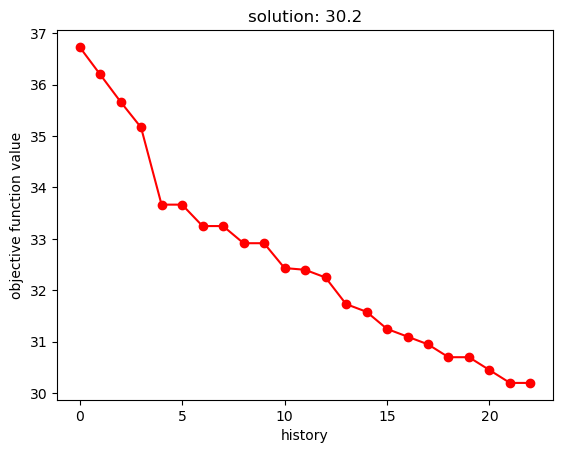

In [3]:
from gurobipy import GRB
import gurobipy as gp
import numpy as np
np.random.seed(0)
import math

class Instance(object):
    
    def __init__(self, num_order, min_order_len=10, max_order_len=50,
                min_demand=1, max_demand=5):
        
        # generates an instance which guarantees feasibility.
        self.n = num_order
        self.order_lens = np.random.randint(min_order_len, max_order_len+1, size=self.n)
        self.demands = np.random.randint(min_demand, max_demand+1, size=self.n)
        self.m = np.sum(self.demands)
        self.roll_len = max_order_len
    
    def summarize(self):
        print("Problem instance with ", self.n, " orders and ", self.m, "rolls")
        print("-"*47)
        print("\nOrders:\n")
        for i, order_len in enumerate(self.order_lens):
            print("\tOrder ", i, ": length= ", order_len, " demand=", self.demands[i])
        print("\nRoll Length: ", self.roll_len)

def optimize_kantorovich(ins_:Instance):
    
    # model
    model = gp.Model("kantorovich_formulation")
    
    # sets (ranges)
    rolls = range(ins_.m)
    orders = range(ins_.n)
    
    # decision variables
    use_roll = model.addVars(rolls,
                             vtype=GRB.BINARY,
                             obj=np.ones(ins_.m),
                             name="X")
    
    how_much_use = model.addVars(orders, rolls, 
                                 vtype=GRB.INTEGER,
                                 obj= np.zeros((ins_.n, ins_.m)), 
                                 name="Y")

    
    # direction of optimization (min or max)
    model.modelSense = GRB.MINIMIZE
    
    # demand satisfaction constraint
    model.addConstrs(
                    (how_much_use.sum(i, '*') == ins_.demands[i] for i in orders), 
                    "Demand"
                    )
    
    # length constraint of a roll
    for j in rolls:
        model.addConstr(sum(how_much_use[i,j]*ins_.order_lens[i] for i in orders)
                        <= ins_.roll_len,
                        "Length[%d]" %j)
    
    # x-y link
    for i in orders:
        for j in rolls:
            model.addConstr(how_much_use[i,j] <= use_roll[j]*ins_.demands[i])
    
    if False:
        model.write('kantorovich.lp') # in case you want to write the model
    
    # solve
    model.optimize()
    
    # display objective function value
    print('\nTotal Number of Rolls Used: ', model.objVal)

instance = Instance(20)
instance.summarize()

optimize_kantorovich(instance)

def generate_initial_patterns(ins_:Instance):
    patterns = []
    for i in range(ins_.n):
        pattern_ = list(np.zeros(ins_.n).astype(int))
        pattern_[i] = int(ins_.roll_len/ins_.order_lens[i])
        patterns.append(pattern_)
    return patterns

def define_master_problem(ins_:Instance, patterns):
    
    n_pattern = len(patterns)
    pattern_range = range(n_pattern)
    order_range = range(ins_.n)
    patterns = np.array(patterns, dtype=int)
    master_problem = gp.Model("master problem")
    
    # decision variables
    lambda_ = master_problem.addVars(pattern_range,
                                     vtype=GRB.CONTINUOUS,
                                     obj=np.ones(n_pattern),
                                     name="lambda")
    
    # direction of optimization (min or max)
    master_problem.modelSense = GRB.MINIMIZE
    
    # demand satisfaction constraint
    for i in order_range:
        master_problem.addConstr(sum(patterns[p,i]*lambda_[p] for p in pattern_range) == ins_.demands[i],
                                 "Demand[%d]" %i)
            
    # solve
    return master_problem


def define_subproblem(ins_:Instance, duals):
    
    order_range = range(ins_.n)
    subproblem = gp.Model("subproblem")
    #z
    # decision variables
    x = subproblem.addVars(order_range,
                           vtype=GRB.INTEGER,
                           obj=duals,
                           name="x")
    
    # subproblem optimization
    subproblem.modelSense = GRB.MAXIMIZE
        
    # Length constraint
    subproblem.addConstr(sum(ins_.order_lens[i] * x[i] for i in order_range) <= ins_.roll_len)
    
    return subproblem


def print_solution(master, patterns):
    use = [math.ceil(i.x) for i in master.getVars()]
    for i, p in enumerate(patterns):
        if use[i]>0:
            print('Pattern ', i, ': how often we should cut: ', use[i])
            print('----------------------')
            for j,order in enumerate(p):
                if order >0:
                    print('order ', j, ' how much: ', order)
            print()

def column_generation(ins_:Instance):
    
    patterns = generate_initial_patterns(ins_)
    objVal_history = []
    while True:
        master_problem = define_master_problem(ins_, patterns)
        master_problem.optimize()
        objVal_history.append(master_problem.objVal)
        dual_variables = np.array([constraint.pi for constraint in master_problem.getConstrs()])
        subproblem = define_subproblem(ins_, dual_variables)
        subproblem.optimize()
        if subproblem.objVal < 1 + 1e-2:
            break
        patterns.append([i.x for i in subproblem.getVars()])
    print_solution(master_problem, patterns)
    print('Total number of rolls used: ', int(np.array([math.ceil(i.x) for i in master_problem.getVars()]).sum()))
    return objVal_history


history = column_generation(instance)

import matplotlib.pyplot as plt
plt.plot(list(range(len(history))), history,c='r')
plt.scatter(list(range(len(history))), history, c='r')
plt.xlabel('history')
plt.ylabel('objective function value')
title = 'solution: ' + str(history[-1])
plt.title(title)
plt.show()

## initial feasible solution

In [9]:
from gurobipy import Model, GRB, quicksum
import math

# -------------------------------
# 1. Define the instance data
# -------------------------------
# List of companies
companies = ['Apple', 'Microsoft', 'Amazon', 'Alphabet', 'Meta', 'Tesla', 'JP', 'Berkshire']
n = len(companies)

# Cost per share for each company (for example)
cost = [110, 150, 160, 240, 120, 220, 80, 350]   # c_i for i=0,...,n-1

# Demand (number of shares required) for each company
demand = [30, 20, 50, 40, 35, 25,60, 15]  # D_i for i=0,...,n-1

# Maximum cost per package
package_limit = 1000

# -------------------------------
# 2. Generate initial patterns

# For each company, create a pattern that consists solely of that company:
# We take as many shares as possible of that company without exceeding package_limit.
patterns = []  # list of patterns; each pattern is a list of integers (shares per company)
for i in range(n):
    pattern = [0] * n
    max_shares = package_limit // cost[i]
    pattern[i] = max_shares
    patterns.append(pattern)

def pattern_cost(pattern):
    """Return total cost of a pattern."""
    total = 0
    for i in range(n):
        total += cost[i] * pattern[i]
    return total

# -------------------------------
# 3. Define the master problem

def solve_master(patterns):
    """
    Solve the master problem with the current set of patterns.
    Returns the model and a list of dual values for the demand constraints.
    """
    master = Model("Master")
    master.Params.OutputFlag = 0  # turn off solver output

    num_patterns = len(patterns)
    # Decision variables: lambda_p for each pattern p (fractional allowed)
    lambdas = []
    for p in range(num_patterns):
        # Cost of pattern p is the sum of cost[i]*pattern[i]
        pat_cost = pattern_cost(patterns[p])
        var = master.addVar(lb=0.0, obj=pat_cost, name="lambda_%d" % p)
        lambdas.append(var)
    master.update()

    # Demand constraints: for each company i, total shares from all patterns >= demand[i]
    for i in range(n):
        master.addConstr(quicksum(patterns[p][i] * lambdas[p] for p in range(num_patterns)) >= demand[i],
                          name="Demand_%d" % i)
    master.modelSense = GRB.MINIMIZE
    master.optimize()

    # Get duals for the demand constraints
    duals = []
    for i in range(n):
        constr = master.getConstrByName("Demand_%d" % i)
        duals.append(constr.Pi)
    return master, duals, lambdas

# -------------------------------
# 4. Define the subproblem (knapsack)

def solve_subproblem(duals):
    
    sub = Model("Subproblem")
    sub.Params.OutputFlag = 0  # no output

    # Decision variables: number of shares x[i] for company i in the new pattern
    x = []
    for i in range(n):
        var = sub.addVar(lb=0, vtype=GRB.INTEGER, name="x_%d" % i)
        x.append(var)
    sub.update()

    # Objective: maximize sum_i duals[i] * x[i]
    sub.setObjective(quicksum(duals[i] * x[i] for i in range(n)), GRB.MAXIMIZE)

    # Constraint: total cost in the package <= package_limit
    sub.addConstr(quicksum(cost[i] * x[i] for i in range(n)) <= package_limit, name="CostLimit")

    sub.optimize()

    # Extract the new pattern
    new_pattern = [int(x[i].X + 0.5) for i in range(n)]  # rounding to integer
    # Also compute the objective value of the subproblem
    sub_obj = sub.objVal
    return new_pattern, sub_obj

# -------------------------------
# 5. Column generation loop

tolerance = 1e-2
iteration = 0
while True:
    iteration += 1
    master, duals, lambdas = solve_master(patterns)
    # Solve subproblem with current dual prices
    new_pattern, sub_obj = solve_subproblem(duals)
    
    # Reduced cost: new_pattern cost - sub_obj; 
    # In column generation for minimization, if subproblem obj <= 1 then no column improves.
    # Here, note that the master objective coefficients are the cost of the pattern.
    # The reduced cost of a new column is: cost(new_pattern) - sum_i dual_i*x[i]
    new_pattern_cost = pattern_cost(new_pattern)
    reduced_cost = new_pattern_cost - sub_obj

    print("Iteration:", iteration, "New pattern:", new_pattern, 
          "Cost:", new_pattern_cost, "Subproblem obj:", sub_obj, 
          "Reduced cost:", reduced_cost)

    # If the reduced cost is not less than -tolerance, stop
    if reduced_cost >= -tolerance:
        break
    # Otherwise, add new pattern to the pool
    patterns.append(new_pattern)

# -------------------------------
# 6. Print final master solution

print("\nFinal Master Problem Solution:")
for i in range(n):
    lhs = sum(patterns[p][i] * lambdas[p].X for p in range(len(patterns)))
    print("Company", companies[i], ": Demand =", demand[i], "Achieved =", lhs)
total_cost = master.objVal
print("Total Cost:", total_cost)

# print the patterns used with nonzero lambda value.
print("\nPatterns used in the optimal solution:")
for p in range(len(patterns)):
    if lambdas[p].X > 1e-5:
        print("Pattern", p, ":", patterns[p], "lambda =", lambdas[p].X)


Iteration: 1 New pattern: [5, 3, 0, 0, 0, 0, 0, 0] Cost: 1000 Subproblem obj: 1000.0 Reduced cost: 0.0

Final Master Problem Solution:
Company Apple : Demand = 30 Achieved = 30.0
Company Microsoft : Demand = 20 Achieved = 20.0
Company Amazon : Demand = 50 Achieved = 50.0
Company Alphabet : Demand = 40 Achieved = 40.0
Company Meta : Demand = 35 Achieved = 35.0
Company Tesla : Demand = 25 Achieved = 25.0
Company JP : Demand = 60 Achieved = 60.0
Company Berkshire : Demand = 15 Achieved = 15.0
Total Cost: 43650.0

Patterns used in the optimal solution:
Pattern 0 : [9, 0, 0, 0, 0, 0, 0, 0] lambda = 3.3333333333333335
Pattern 1 : [0, 6, 0, 0, 0, 0, 0, 0] lambda = 3.3333333333333335
Pattern 2 : [0, 0, 6, 0, 0, 0, 0, 0] lambda = 8.333333333333334
Pattern 3 : [0, 0, 0, 4, 0, 0, 0, 0] lambda = 10.0
Pattern 4 : [0, 0, 0, 0, 8, 0, 0, 0] lambda = 4.375
Pattern 5 : [0, 0, 0, 0, 0, 4, 0, 0] lambda = 6.25
Pattern 6 : [0, 0, 0, 0, 0, 0, 12, 0] lambda = 5.0
Pattern 7 : [0, 0, 0, 0, 0, 0, 0, 2] lambda = 

## solution to the problem

In [43]:
import gurobipy as gp
from gurobipy import GRB
import math



def solve_portfolio_column_generation():

    # --------------------------
    # 1) Problem Data

    # We have 8 companies, each with a required demand (in shares) and a cost per share.
    # The total cost of shares in any package must not exceed 1000 USD.
    # Each purchased package (pattern) is assumed to cost 900 USD in the master problem.
    companies = ["Apple Inc", "Microsoft Corp", "Amazon.com Inc", "Alphabet Inc",
                 "Meta Platforms Inc", "Tesla Inc", "JPMorgan Chase", "Berkshire Hathaway"]
    
    demands = [30, 20, 50, 40, 35, 25, 60, 15]   # shares needed
    costs   = [110,150,160,240,120,220,80,350]     # cost per share (USD)

    n = len(companies)
    CAPACITY = 1000.0  # maximum total cost of shares per package
    PACKAGE_COST = 900.0  # fixed cost per package in the master problem

    # --------------------------
    # 2) Generate Initial Patterns

    def generate_initial_patterns():
        """
        Create a simple initial pattern set: 
        For each company i, put as many shares of that company alone 
        as fit into the 1000-USD capacity.
        """
        patterns = []
        for i in range(n):
            pattern = [0] * n
            max_shares = int(CAPACITY // costs[i])  # largest integer number of shares that fits
            if max_shares > 0:
                pattern[i] = max_shares
                patterns.append(pattern)
        return patterns
    

    # --------------------------
    # 3) Master Problem

    def define_master_problem(patterns):

        m = gp.Model("master_portfolio")
        m.setParam("OutputFlag", 0)  

        # Decision variables: fraction of each pattern to use (continuous)
        lambdas = []
        for p in range(len(patterns)):
            lambdas.append(
                m.addVar(
                    vtype=GRB.CONTINUOUS,
                    lb=0.0,
                    obj=PACKAGE_COST,  # each pattern costs 900 in the objective
                    name=f"lambda_{p}"
                )
            )

        m.modelSense = GRB.MINIMIZE
        m.update()

        # Demand constraints: for each company i, we need sum_{p} patterns[p][i]*lambda_p >= demands[i]
        for i in range(n):
            m.addConstr(
                gp.quicksum(patterns[p][i] * lambdas[p] for p in range(len(patterns))) >= demands[i],
                name=f"demand_{i}"
            )

        m.update()
        return m

    # --------------------------
    # 4) Subproblem

    def define_subproblem(duals):
        """
        Build an IP that chooses integer shares (how many shares of company i to put in a package),
        subject to sum_i(costs[i]*x_i) <= CAPACITY. 
        Objective: maximize sum_{i} (duals[i]*x_i).

        If the optimum is greater than PACKAGE_COST, then the reduced cost is negative,
        meaning we add that pattern.
        """
        sp = gp.Model("subproblem_package_design")
        sp.setParam("OutputFlag", 0)  # mute solver output

        # x[i] = number of shares of company i in the new pattern
        x = []
        for i in range(n):
            x.append(
                sp.addVar(vtype=GRB.INTEGER, lb=0, obj=duals[i], name=f"x_{i}")
            )

        sp.modelSense = GRB.MAXIMIZE
        sp.update()

        # Capacity constraint
        sp.addConstr(
            gp.quicksum(costs[i] * x[i] for i in range(n)) <= CAPACITY,
            name="capacity"
        )
        
        sp.update()
        return sp

    # --------------------------
    # Print the Initial Feasible Base
    # Generate the initial patterns and solve the master problem using them.
    
    initial_patterns = generate_initial_patterns()
    master_initial = define_master_problem(initial_patterns)
    master_initial.optimize()
    
    print("Initial Feasible Base:")
    lam_vars = master_initial.getVars()
    for p, lam in enumerate(lam_vars):
        if lam.X > 1e-6:
            print(f"  Pattern {p}: {initial_patterns[p]} used {lam.X:.3f} times")
    
    # Calculate total shares provided by the initial patterns
    total_shares = [0] * n
    for p, lam in enumerate(lam_vars):
        for i in range(n):
            total_shares[i] += initial_patterns[p][i] * lam.X
    
    print("\nShares Provided by Initial Feasible Base:")
    for i, comp in enumerate(companies):
        print(f"  {comp}: needed = {demands[i]}, bought = {total_shares[i]:.3f}")

    # --------------------------
    # 5) Column Generation

    def column_generation():
        # Start with some initial patterns
        patterns = generate_initial_patterns()
        obj_history = []
        iteration = 0

        while True:
            iteration += 1
            # Build and solve the current master problem
            master = define_master_problem(patterns)
            master.optimize()
            
            obj_val = master.objVal
            obj_history.append(obj_val)

            # Get duals from the demand constraints
            duals = [con.Pi for con in master.getConstrs()]

            # Solve the subproblem (knapsack) to find a new pattern
            sp = define_subproblem(duals)
            sp.optimize()
            sub_obj = sp.objVal

            # Extract new pattern from subproblem
            new_pattern = [int(v.X) for v in sp.getVars()]
            # Calculate the actual cost of the new pattern
            new_pattern_cost = sum(costs[i] * new_pattern[i] for i in range(n))
            # Compute reduced cost: difference between new pattern cost and subproblem obj
            reduced_cost = 900 - sub_obj

            # Print iteration information
            print("Iteration:", iteration,
                  "New pattern:", new_pattern,
                  "Cost:", new_pattern_cost,
                  "Subproblem obj:", sub_obj,
                  "Reduced cost:", reduced_cost)

            # Reduced cost check:
            # In the master, the pattern's cost is PACKAGE_COST.
            # If sub_obj <= PACKAGE_COST, no pattern with negative reduced cost exists.
            if sub_obj <= PACKAGE_COST + 1e-6:
                # No improvement -> stop column generation
                break
            else:
                # Otherwise, add the new pattern to the pool and iterate.
                patterns.append(new_pattern)

        return master, patterns, obj_history

    # --------------------------
    # 6) Run Column Generation

    master, patterns, obj_history = column_generation()
    master.optimize()

    # --------------------------
    # 7) Print Results

    print("Final Objective (Total Cost) =", master.objVal)
    print("Patterns used:")
    lam_vars = master.getVars()
    for p, lam in enumerate(lam_vars):
        if lam.X > 1e-6:
            print(f"  Pattern {p} is used {lam.X:.3f} times -> {patterns[p]}")

    # Calculate how many shares each pattern set provides and confirm demands are met.
    total_shares = [0] * n
    for p, lam in enumerate(lam_vars):
        for i in range(n):
            total_shares[i] += patterns[p][i] * lam.X

    print("\nShares Provided:")
    for i, comp in enumerate(companies):
        print(f"  {comp}: needed={demands[i]}, bought={total_shares[i]:.3f}")


solve_portfolio_column_generation()



Initial Feasible Base:
  Pattern 0: [9, 0, 0, 0, 0, 0, 0, 0] used 3.333 times
  Pattern 1: [0, 6, 0, 0, 0, 0, 0, 0] used 3.333 times
  Pattern 2: [0, 0, 6, 0, 0, 0, 0, 0] used 8.333 times
  Pattern 3: [0, 0, 0, 4, 0, 0, 0, 0] used 10.000 times
  Pattern 4: [0, 0, 0, 0, 8, 0, 0, 0] used 4.375 times
  Pattern 5: [0, 0, 0, 0, 0, 4, 0, 0] used 6.250 times
  Pattern 6: [0, 0, 0, 0, 0, 0, 12, 0] used 5.000 times
  Pattern 7: [0, 0, 0, 0, 0, 0, 0, 2] used 7.500 times

Shares Provided by Initial Feasible Base:
  Apple Inc: needed = 30, bought = 30.000
  Microsoft Corp: needed = 20, bought = 20.000
  Amazon.com Inc: needed = 50, bought = 50.000
  Alphabet Inc: needed = 40, bought = 40.000
  Meta Platforms Inc: needed = 35, bought = 35.000
  Tesla Inc: needed = 25, bought = 25.000
  JPMorgan Chase: needed = 60, bought = 60.000
  Berkshire Hathaway: needed = 15, bought = 15.000
Iteration: 1 New pattern: [0, 2, 0, 0, 0, 0, 0, 2] Cost: 1000 Subproblem obj: 1200.0 Reduced cost: -300.0
Iteration: 2 N